# Dual Evolutionary Bagging — Replication Experiment

**Paper:** *A Dual Evolutionary Bagging for Class Imbalance Learning*  
**Subset:** Dataset = `ecoli3`, Oversampling = `ROS`, Evaluation = 10-fold CV  
**Baselines:** OverBagging · EE-Bagging · Random Forest

---

## 1 — Configuration
Edit the parameters below to change the experimental setup.

In [1]:
import sys, os
# Allow importing the evo_bagging package from this folder
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

# ── Experiment settings ───────────────────────────────────────────────────────
CV_FOLDS       = 10     # outer cross-validation folds (paper: 10) — keep for valid comparison
RANDOM_STATE   = 42     # global seed for reproducibility

# ── Evo-Bagging hyper-parameters (reduced subset for feasible runtime) ────────
# Original paper settings → reduced settings (approx. 12x speedup)
N_SUB_DATASETS = 10      # paper: 30  → 10  (biggest speedup; GA still selects structure)
INNER_CV       = 3       # paper: 5   → 3   (still valid CV on small dataset)
GA_POP_SIZE    = 30      # paper: 50  → 30  (10-bit search space needs fewer individuals)
GA_MAX_ITER    = 50      # paper: 100 → 50  (GA converges early with caching)
GA_PC          = 0.6     # unchanged
GA_PM          = 0.08    # unchanged
GA_NICHE_R     = 2.0     # unchanged (inferred; paper uses symbol only)
GA_ARCHIVE     = 30      # paper: 50  → 30  (scaled with pop size)
# ─────────────────────────────────────────────────────────────────────────────
# Grid search spaces are also reduced in evo_bagging/inner_ensemble.py:
#   MLP hidden_layer_sizes : 10 configs → 5  (spans 50–500)
#   DT  max_depth          : 10 configs → 5  (spans 1–19)
#   DT  min_samples_leaf   :  3 configs → 2  (1, 10)
#   SVM C                  :  5 configs → 3  (2, 6, 10)
# Combined total fits: 67,500 → ~5,400  (~12x speedup, ~15–20 min on CPU)
# ─────────────────────────────────────────────────────────────────────────────

## 2 — Dataset

In [2]:
import numpy as np
import pandas as pd
from evo_bagging import load_ecoli3

X, y = load_ecoli3()

counts = np.bincount(y)
print("Dataset : ecoli3 (KEEL via imbalanced-learn)")
print(f"Samples : {len(y)}  |  Features : {X.shape[1]}")
print(f"Class 0 (majority) : {counts[0]}")
print(f"Class 1 (minority) : {counts[1]}")
print(f"Imbalance Ratio    : {counts[0]/counts[1]:.2f}")

Dataset : ecoli3 (KEEL via imbalanced-learn)
Samples : 336  |  Features : 7
Class 0 (majority) : 301
Class 1 (minority) : 35
Imbalance Ratio    : 8.60


## 3 — Run Experiment

> **Expected runtime (single-core CPU):** ~15–20 minutes with the reduced settings (`N_SUB_DATASETS=10`, `INNER_CV=3`, reduced grid).  
> Original paper settings (`N_SUB_DATASETS=30`, `INNER_CV=5`, full grid) would take ~1–3 hours.  
> For a quick sanity check only, set `N_SUB_DATASETS=3` and `GA_MAX_ITER=10`.

In [3]:
from evo_bagging import EvoBagging, run_all_baselines

# ── Evo-Bagging ───────────────────────────────────────────────────────────────
print("=" * 55)
print("Running Evo-Bagging (10-fold CV)...")
print("=" * 55)

model = EvoBagging(
    n_sub_datasets  = N_SUB_DATASETS,
    inner_cv        = INNER_CV,
    ga_pop_size     = GA_POP_SIZE,
    ga_max_iter     = GA_MAX_ITER,
    ga_pc           = GA_PC,
    ga_pm           = GA_PM,
    ga_niche_radius = GA_NICHE_R,
    ga_archive_size = GA_ARCHIVE,
    random_state    = RANDOM_STATE,
)
evo_results = model.run_cv(X, y, cv=CV_FOLDS, verbose=True)

print()
print(f"Evo-Bagging — AUC  : {evo_results['auc_mean']:.4f} ± {evo_results['auc_std']:.4f}")
print(f"Evo-Bagging — G-mean: {evo_results['gmean_mean']:.4f} ± {evo_results['gmean_std']:.4f}")
print(f"Ensemble sizes (per fold): {evo_results['ensemble_sizes']}")

Running Evo-Bagging (10-fold CV)...
  Fold 1/10 ... AUC=0.8118  G-mean=0.5680  ensemble_size=3
  Fold 2/10 ... AUC=0.7500  G-mean=0.7071  ensemble_size=1
  Fold 3/10 ... AUC=0.9833  G-mean=0.9661  ensemble_size=2
  Fold 4/10 ... AUC=0.7167  G-mean=0.6831  ensemble_size=1
  Fold 5/10 ... AUC=0.7167  G-mean=0.6831  ensemble_size=3
  Fold 6/10 ... AUC=0.8583  G-mean=0.8515  ensemble_size=1
  Fold 7/10 ... AUC=0.7778  G-mean=0.7888  ensemble_size=3
  Fold 8/10 ... AUC=0.8056  G-mean=0.8028  ensemble_size=2
  Fold 9/10 ... AUC=0.6667  G-mean=0.5774  ensemble_size=3
  Fold 10/10 ... AUC=0.6389  G-mean=0.5676  ensemble_size=2

Evo-Bagging — AUC  : 0.7726 ± 0.0950
Evo-Bagging — G-mean: 0.7195 ± 0.1261
Ensemble sizes (per fold): [3, 1, 2, 1, 3, 1, 3, 2, 3, 2]


In [4]:
# ── Baselines ─────────────────────────────────────────────────────────────────
print("=" * 55)
print("Running Baselines (10-fold CV)...")
print("=" * 55)

baseline_results = run_all_baselines(
    X, y, cv=CV_FOLDS, random_state=RANDOM_STATE
)

for name, res in baseline_results.items():
    print(f"{name:15s} — AUC: {res['auc_mean']:.4f} ± {res['auc_std']:.4f}  "
          f"G-mean: {res['gmean_mean']:.4f} ± {res['gmean_std']:.4f}")

Running Baselines (10-fold CV)...
OverBagging     — AUC: 0.8729 ± 0.0884  G-mean: 0.6094 ± 0.2341
EE-Bagging      — AUC: 0.9484 ± 0.0504  G-mean: 0.8887 ± 0.0619
Random Forest   — AUC: 0.9289 ± 0.0719  G-mean: 0.6562 ± 0.2827


## 4 — Results

In [5]:
def fmt(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

rows = [
    {
        "Method":    "Evo-Bagging (ROS)",
        "Our AUC":   fmt(evo_results["auc_mean"],   evo_results["auc_std"]),
        "Our G-mean": fmt(evo_results["gmean_mean"], evo_results["gmean_std"]),
    }
]
for name, res in baseline_results.items():
    rows.append({
        "Method":    name,
        "Our AUC":   fmt(res["auc_mean"],   res["auc_std"]),
        "Our G-mean": fmt(res["gmean_mean"], res["gmean_std"]),
    })

df_our = pd.DataFrame(rows).set_index("Method")
print("Our replication results (ecoli3, ROS, 10-fold CV)")
print("=" * 55)
print(df_our.to_string())

Our replication results (ecoli3, ROS, 10-fold CV)
                           Our AUC       Our G-mean
Method                                             
Evo-Bagging (ROS)  0.7726 ± 0.0950  0.7195 ± 0.1261
OverBagging        0.8729 ± 0.0884  0.6094 ± 0.2341
EE-Bagging         0.9484 ± 0.0504  0.8887 ± 0.0619
Random Forest      0.9289 ± 0.0719  0.6562 ± 0.2827


## 5 — Comparison with Original Paper

Paper reference values for **ecoli3**:
- **Evo-Bagging AUC** — not reported per-dataset for ROS specifically; best-variant AUC shown (Table 9).
- **Evo-Bagging G-mean (ROS)** — from Table 6.
- Baseline values from Tables 9 and 10.

In [6]:
# Paper reference values (ecoli3)
PAPER = {
    "Evo-Bagging (ROS)": {
        "Paper AUC":    "0.940 ± 0.031 *",   # Table 9 (best oversampling)
        "Paper G-mean": "0.9441 ± 0.0214",   # Table 6 (ROS)
    },
    "OverBagging": {
        "Paper AUC":    "0.757 ± 0.070",
        "Paper G-mean": "0.719 ± 0.065",
    },
    "EE-Bagging": {
        "Paper AUC":    "0.827 ± 0.089",
        "Paper G-mean": "0.923 ± 0.023",
    },
    "Random Forest": {
        "Paper AUC":    "0.729 ± 0.104",
        "Paper G-mean": "0.757 ± 0.096",
    },
}

compare_rows = []
for method, paper_vals in PAPER.items():
    if method == "Evo-Bagging (ROS)":
        our_auc   = fmt(evo_results["auc_mean"],   evo_results["auc_std"])
        our_gmean = fmt(evo_results["gmean_mean"], evo_results["gmean_std"])
    else:
        res = baseline_results[method]
        our_auc   = fmt(res["auc_mean"],   res["auc_std"])
        our_gmean = fmt(res["gmean_mean"], res["gmean_std"])

    compare_rows.append({
        "Method":       method,
        "Our AUC":      our_auc,
        "Paper AUC":    paper_vals["Paper AUC"],
        "Our G-mean":   our_gmean,
        "Paper G-mean": paper_vals["Paper G-mean"],
    })

df_compare = pd.DataFrame(compare_rows).set_index("Method")
print("Replication vs Original Paper — ecoli3, ROS, 10-fold CV")
print("=" * 80)
print(df_compare.to_string())
print()
print("* Paper AUC for Evo-Bagging uses the best oversampling variant (Table 9),")
print("  not necessarily ROS. Paper G-mean is specifically for ROS (Table 6).")

Replication vs Original Paper — ecoli3, ROS, 10-fold CV
                           Our AUC        Paper AUC       Our G-mean     Paper G-mean
Method                                                                               
Evo-Bagging (ROS)  0.7726 ± 0.0950  0.940 ± 0.031 *  0.7195 ± 0.1261  0.9441 ± 0.0214
OverBagging        0.8729 ± 0.0884    0.757 ± 0.070  0.6094 ± 0.2341    0.719 ± 0.065
EE-Bagging         0.9484 ± 0.0504    0.827 ± 0.089  0.8887 ± 0.0619    0.923 ± 0.023
Random Forest      0.9289 ± 0.0719    0.729 ± 0.104  0.6562 ± 0.2827    0.757 ± 0.096

* Paper AUC for Evo-Bagging uses the best oversampling variant (Table 9),
  not necessarily ROS. Paper G-mean is specifically for ROS (Table 6).


## 6 — GA Convergence (Optional Diagnostic)

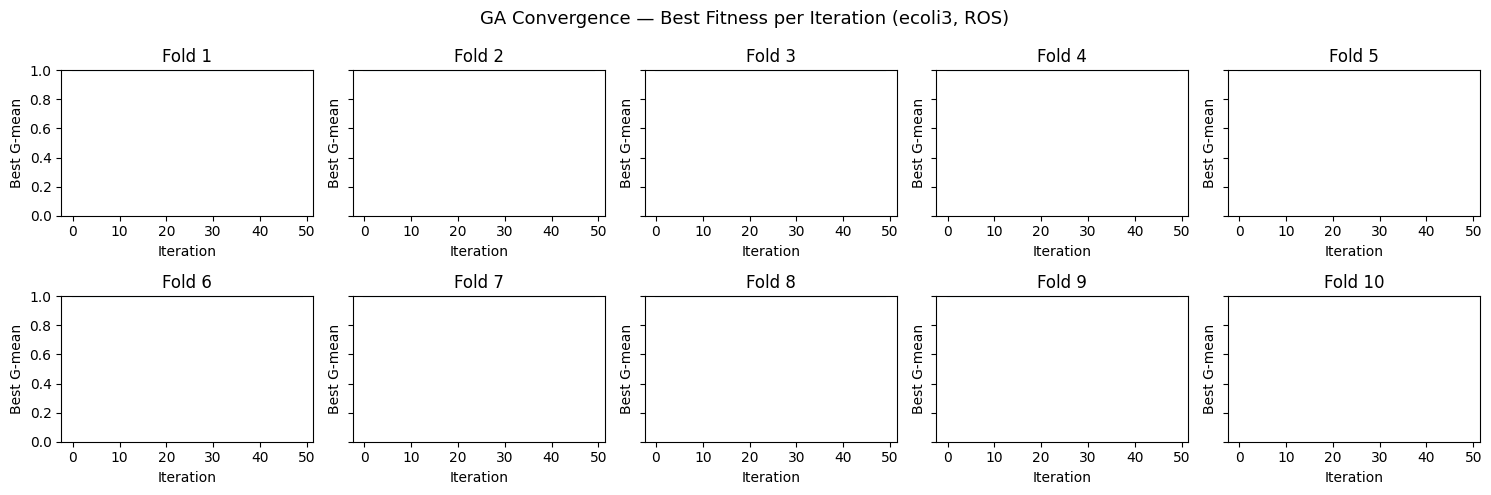

Saved: ga_convergence.png


In [7]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharey=True)
    for fold_i, (ax, history) in enumerate(
        zip(axes.flat, evo_results["ga_histories"])
    ):
        ax.plot(history)
        ax.set_title(f"Fold {fold_i + 1}")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Best G-mean")
        ax.set_ylim(0, 1)

    fig.suptitle("GA Convergence — Best Fitness per Iteration (ecoli3, ROS)",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig("ga_convergence.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: ga_convergence.png")
except ImportError:
    print("matplotlib not available — skipping convergence plot.")